# UK Banking Fraud Detection Model
**Author:** Sahil Singh Choudhary  
**Tools:** Python, pandas, scikit-learn, shap, matplotlib, seaborn  
**Context:** UK Retail Banking — Transaction Fraud Detection

---

## What is this project?

In 2023, fraud losses in the UK totalled **£1.17 billion** according to UK Finance. Every major UK bank — Barclays, Lloyds, HSBC, NatWest — and every fintech — Monzo, Revolut, Starling — runs automated fraud detection models in real time.

This project builds a **machine learning fraud detection model** on synthetic UK banking transaction data. The model flags suspicious transactions before they are processed — the same core task performed by fraud analytics teams at UK banks.

### UK Regulatory Context:
- **PSD2 (Payment Services Directive 2)** — EU/UK regulation requiring banks to perform real-time fraud monitoring
- **FCA Consumer Duty (2023)** — Banks must demonstrate they are protecting customers from financial harm, including fraud
- **Contingent Reimbursement Model (CRM)** — UK voluntary code requiring banks to reimburse fraud victims

### What we will do, step by step:
1. **Generate realistic UK banking transaction data** — GBP amounts, UK merchants, UK cities
2. **Explore the data** — understand fraud patterns
3. **Engineer features** — build signals including customer velocity
4. **Build and compare models** — Logistic Regression, Random Forest, and Gradient Boosting
5. **Cross-validate** — robust evaluation beyond a single train/test split
6. **Evaluate using the right metrics** — Precision, Recall, AUC-PR
7. **Set a business threshold** — balance catching fraud vs. blocking legitimate transactions
8. **Explain predictions with SHAP** — understand why each transaction is flagged
9. **Save the model** — ready for deployment
10. **Translate to business recommendations**

---

### Why synthetic data?
Real bank transaction data is highly confidential. In practice, fraud teams use **synthetic data** for model development — it mirrors real patterns while protecting customer privacy.

---
## Step 1: Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, make_scorer
)

try:
    import shap
    SHAP_AVAILABLE = True
    print('shap available')
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — run: pip install shap')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 6)

print('Libraries imported successfully')

shap available
Libraries imported successfully


---
## Step 2: Generate Synthetic UK Banking Transaction Data

We generate **200,000 transactions** that mirror the patterns of a UK retail bank.

Each transaction has:
- A customer ID, amount in GBP
- UK merchant category and merchant name
- UK city and transaction channel (contactless, online, ATM, etc.)
- Whether the transaction is fraudulent (our target variable)

Fraud is roughly **0.8%** of transactions — realistic for UK card fraud.

In [18]:
N = 200_000
FRAUD_RATE = 0.008

uk_cities = [
    'London', 'Manchester', 'Birmingham', 'Leeds', 'Glasgow',
    'Liverpool', 'Edinburgh', 'Bristol', 'Sheffield', 'Leicester',
    'Nottingham', 'Newcastle', 'Cardiff', 'Brighton', 'Oxford'
]

merchant_categories = [
    'Grocery', 'Restaurant', 'Transport', 'Retail', 'Online Shopping',
    'Utilities', 'Entertainment', 'Healthcare', 'Travel', 'ATM Withdrawal'
]

uk_merchants = {
    'Grocery':         ['Tesco', 'Sainsburys', 'ASDA', 'Morrisons', 'Waitrose', 'Lidl', 'Aldi'],
    'Restaurant':      ['McDonalds UK', 'Pret A Manger', 'Greggs', 'Nandos', 'Wagamama'],
    'Transport':       ['TfL Oyster', 'National Rail', 'Uber UK', 'Trainline', 'FirstGroup'],
    'Retail':          ['Marks & Spencer', 'Next', 'Primark', 'John Lewis', 'ASOS'],
    'Online Shopping': ['Amazon UK', 'eBay UK', 'Argos', 'Currys', 'Very'],
    'Utilities':       ['British Gas', 'EDF Energy', 'Thames Water', 'BT', 'Sky'],
    'Entertainment':   ['Netflix UK', 'Spotify UK', 'Odeon', 'Vue Cinema', 'Sky Sports'],
    'Healthcare':      ['Boots', 'Superdrug', 'Lloyds Pharmacy', 'BUPA', 'AXA Health'],
    'Travel':          ['easyJet', 'British Airways', 'Booking.com', 'Airbnb UK', 'TUI'],
    'ATM Withdrawal':  ['Barclays ATM', 'Lloyds ATM', 'NatWest ATM', 'HSBC ATM', 'Santander ATM']
}

channels = ['Contactless', 'Chip and PIN', 'Online', 'ATM', 'Mobile App']

spend_params = {
    'Grocery':         (35, 20),
    'Restaurant':      (25, 15),
    'Transport':       (18, 12),
    'Retail':          (55, 40),
    'Online Shopping': (65, 50),
    'Utilities':       (80, 30),
    'Entertainment':   (20, 10),
    'Healthcare':      (30, 20),
    'Travel':          (180, 120),
    'ATM Withdrawal':  (100, 50)
}

print('UK reference data defined.')
print(f'Generating {N:,} transactions...')

UK reference data defined.
Generating 200,000 transactions...


In [19]:
n_legit = int(N * (1 - FRAUD_RATE))
n_fraud = N - n_legit

def generate_transactions(n, is_fraud=False):
    categories = np.random.choice(merchant_categories, n)
    amounts = []
    merchants = []
    for cat in categories:
        mean, std = spend_params[cat]
        if is_fraud:
            amount = abs(np.random.normal(mean * 2.5, std * 3))
            amount = min(amount, 2500)
        else:
            amount = abs(np.random.normal(mean, std))
            amount = max(amount, 0.50)
        amounts.append(round(amount, 2))
        merchants.append(np.random.choice(uk_merchants[cat]))

    # Legit: daytime peak (sums to 1.0)
    # Fraud: night-heavy (sums to 1.0)
    hours = np.random.choice(
        range(24), n,
        p=([0.01]*6 + [0.03]*4 + [0.07]*4 + [0.07]*4 + [0.05]*4 + [0.03]*2)
        if not is_fraud else
        ([0.07]*6 + [0.02]*4 + [0.03]*4 + [0.03]*4 + [0.04]*4 + [0.05]*2)
    )

    return pd.DataFrame({
        'customer_id':       np.random.randint(1000, 9999, n),
        'amount_gbp':        amounts,
        'merchant_category': categories,
        'merchant_name':     merchants,
        'city':              np.random.choice(uk_cities, n),
        'channel':           np.random.choice(
                                 channels, n,
                                 p=[0.35, 0.25, 0.25, 0.10, 0.05] if not is_fraud
                                 else [0.05, 0.05, 0.60, 0.15, 0.15]
                             ),
        'hour_of_day':       hours,
        'is_foreign':        np.random.choice([0, 1], n, p=[0.95, 0.05] if not is_fraud else [0.55, 0.45]),
        'is_fraud':          int(is_fraud)
    })

df_legit = generate_transactions(n_legit, is_fraud=False)
df_fraud = generate_transactions(n_fraud, is_fraud=True)
df = pd.concat([df_legit, df_fraud], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset generated: {len(df):,} total transactions')
print(f'  Legitimate: {n_legit:,} ({(1-FRAUD_RATE)*100:.1f}%)')
print(f'  Fraudulent: {n_fraud:,} ({FRAUD_RATE*100:.1f}%)')
df.head()

Dataset generated: 200,000 total transactions
  Legitimate: 198,400 (99.2%)
  Fraudulent: 1,600 (0.8%)


,customer_id,amount_gbp,merchant_category,merchant_name,city,channel,hour_of_day,is_foreign,is_fraud
0,6390,93.28,Utilities,EDF Energy,Leeds,Chip and PIN,10,0,0
1,7945,70.23,Utilities,EDF Energy,Bristol,Chip and PIN,17,0,0
2,9732,31.34,Grocery,Aldi,Birmingham,Contactless,12,0,0
3,3402,64.86,Healthcare,AXA Health,Cardiff,Online,9,0,0
4,9383,0.78,Healthcare,AXA Health,Oxford,Contactless,8,0,0


---
## Step 3: Exploratory Data Analysis

Before building any model we explore the data to find patterns that separate fraud from legitimate transactions.

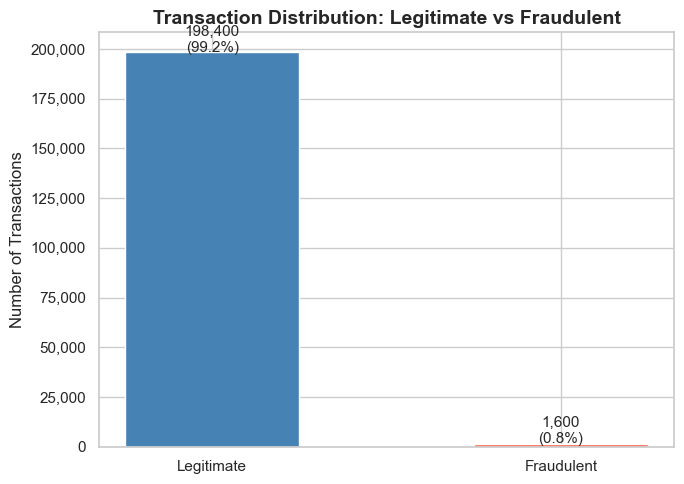

Insight: Fraud is rare at 0.8%. A model predicting not-fraud for everything
would get 99.2% accuracy but catch zero fraud. Accuracy is useless here.


In [20]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct    = df['is_fraud'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
               color=['steelblue', 'tomato'], width=0.5)
ax.set_title('Transaction Distribution: Legitimate vs Fraudulent', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, count, pct in zip(bars, fraud_counts.values, fraud_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('fraud_distribution.png', dpi=150)
plt.show()
print('Insight: Fraud is rare at 0.8%. A model predicting not-fraud for everything')
print('would get 99.2% accuracy but catch zero fraud. Accuracy is useless here.')

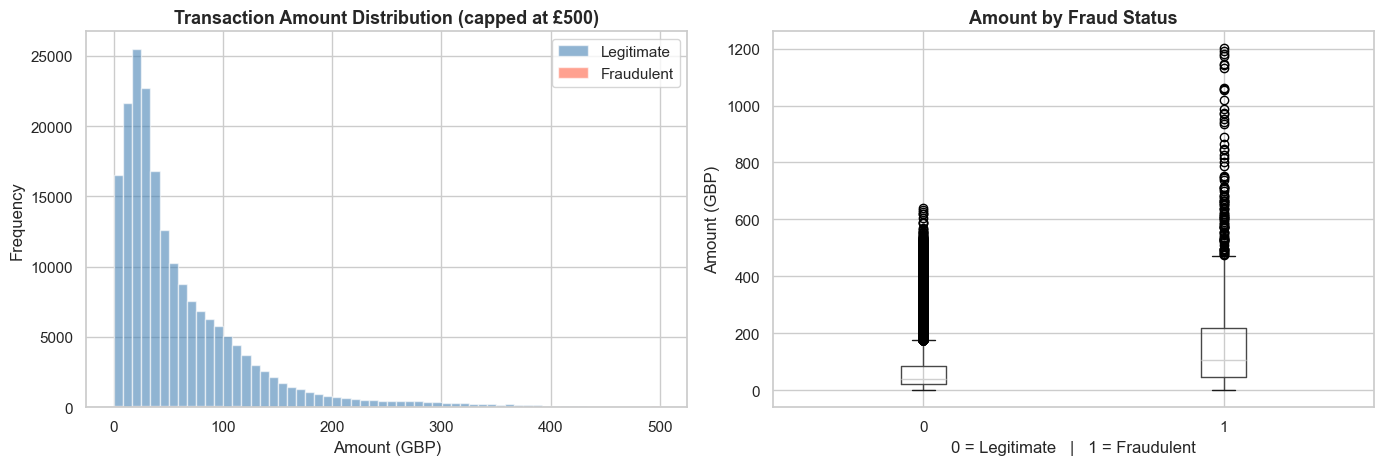

Average legitimate transaction: GBP 62.71
Average fraudulent transaction: GBP 163.50
Insight: Fraudulent transactions are significantly higher in value.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['is_fraud']==0]['amount_gbp'].clip(upper=500).plot(
    kind='hist', bins=60, ax=axes[0], alpha=0.6, color='steelblue', label='Legitimate')
df[df['is_fraud']==1]['amount_gbp'].clip(upper=500).plot(
    kind='hist', bins=60, ax=axes[0], alpha=0.6, color='tomato', label='Fraudulent')
axes[0].set_title('Transaction Amount Distribution (capped at £500)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount (GBP)')
axes[0].legend()

df.boxplot(column='amount_gbp', by='is_fraud', ax=axes[1])
axes[1].set_title('Amount by Fraud Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('0 = Legitimate   |   1 = Fraudulent')
axes[1].set_ylabel('Amount (GBP)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

avg_legit = df[df['is_fraud']==0]['amount_gbp'].mean()
avg_fraud = df[df['is_fraud']==1]['amount_gbp'].mean()
print(f'Average legitimate transaction: GBP {avg_legit:.2f}')
print(f'Average fraudulent transaction: GBP {avg_fraud:.2f}')
print('Insight: Fraudulent transactions are significantly higher in value.')

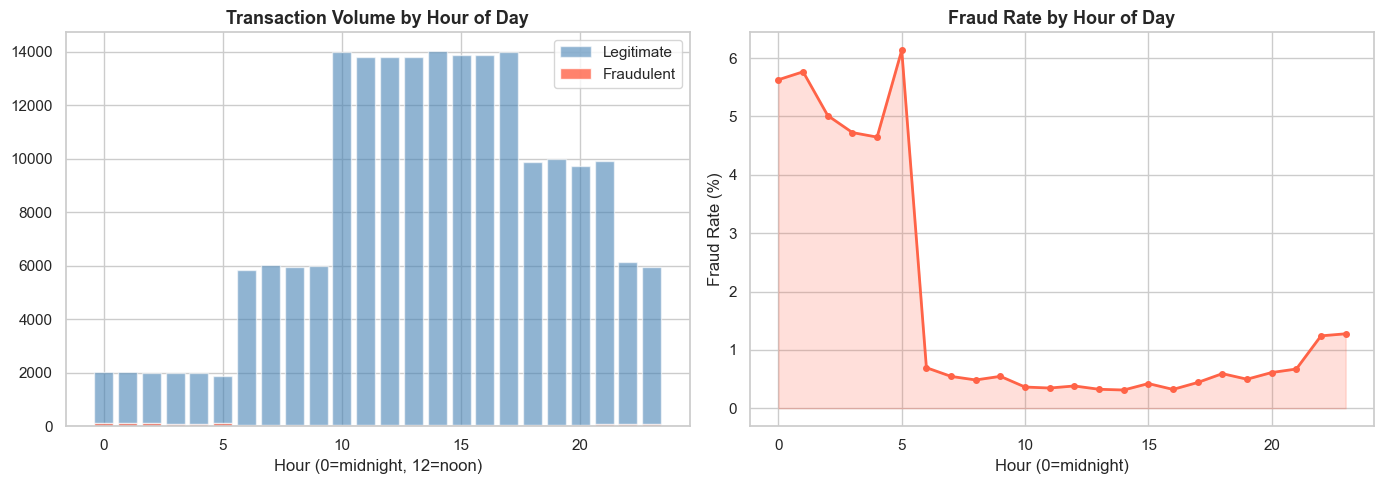

Fraud rate peaks at 5:00.
Overnight transactions are disproportionately fraudulent.
UK banks use this to trigger enhanced authentication at high-risk hours.


In [22]:
fraud_by_hour = df[df['is_fraud']==1].groupby('hour_of_day').size()
legit_by_hour = df[df['is_fraud']==0].groupby('hour_of_day').size()
fraud_rate_by_hour = (fraud_by_hour / (fraud_by_hour + legit_by_hour) * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(legit_by_hour.index, legit_by_hour.values, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, alpha=0.8, color='tomato', label='Fraudulent')
axes[0].set_title('Transaction Volume by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour (0=midnight, 12=noon)')
axes[0].legend()

axes[1].plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
             color='tomato', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(fraud_rate_by_hour.index, fraud_rate_by_hour.values, alpha=0.2, color='tomato')
axes[1].set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour (0=midnight)')
axes[1].set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150)
plt.show()

peak_hour = fraud_rate_by_hour.idxmax()
print(f'Fraud rate peaks at {peak_hour}:00.')
print('Overnight transactions are disproportionately fraudulent.')
print('UK banks use this to trigger enhanced authentication at high-risk hours.')

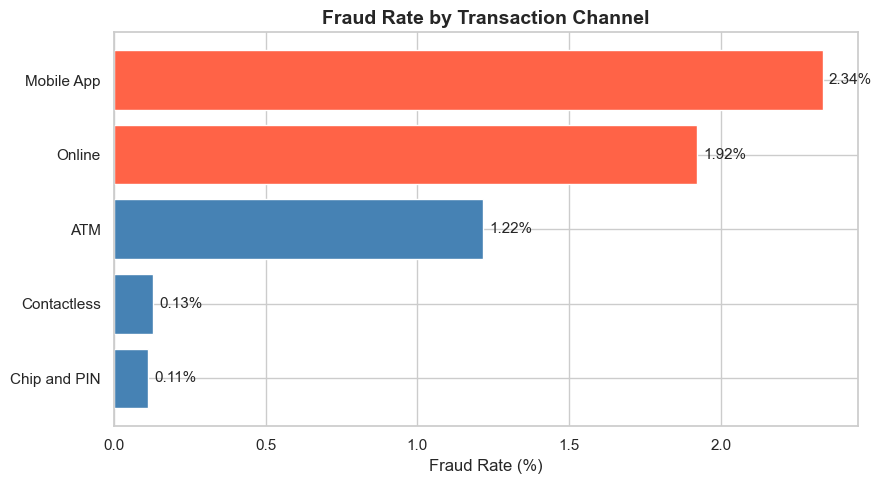

Insight: Online transactions have the highest fraud rate.
UK Finance 2023: Card Not Present (CNP) fraud = 76% of all UK card fraud losses.
PSD2 Strong Customer Authentication was introduced to address this.


In [23]:
channel_fraud = df.groupby('channel')['is_fraud'].mean() * 100
channel_fraud = channel_fraud.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > channel_fraud.median() else 'steelblue' for v in channel_fraud.values]
bars = ax.barh(channel_fraud.index, channel_fraud.values, color=colors)
ax.set_title('Fraud Rate by Transaction Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)')
for bar, val in zip(bars, channel_fraud.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('fraud_by_channel.png', dpi=150)
plt.show()

print('Insight: Online transactions have the highest fraud rate.')
print('UK Finance 2023: Card Not Present (CNP) fraud = 76% of all UK card fraud losses.')
print('PSD2 Strong Customer Authentication was introduced to address this.')

---
## Step 4: Feature Engineering

We create new features that capture fraud signals more precisely. This is where domain knowledge matters.

**Key addition — Customer Velocity:** counts how many transactions each customer has in the dataset. High-frequency customers are a known fraud signal — fraudsters often run multiple small test transactions before a large fraudulent one. This mirrors what velocity rules in UK fraud systems actually check.

In [24]:
# 1. High-risk time window (midnight to 6am)
df['is_night'] = df['hour_of_day'].apply(lambda h: 1 if h < 6 else 0)

# 2. Card Not Present — online or mobile app (no physical card used)
df['is_card_not_present'] = df['channel'].apply(
    lambda c: 1 if c in ['Online', 'Mobile App'] else 0
)

# 3. Amount unusually high for that merchant category (above 95th percentile)
cat_95th = df.groupby('merchant_category')['amount_gbp'].quantile(0.95)
df['amount_above_95th'] = df.apply(
    lambda row: 1 if row['amount_gbp'] > cat_95th[row['merchant_category']] else 0, axis=1
)

# 4. Amount risk tier
df['amount_tier'] = pd.cut(df['amount_gbp'],
                            bins=[0, 20, 50, 100, 250, float('inf')],
                            labels=[0, 1, 2, 3, 4]).astype(int)

# 5. Customer velocity — transaction count per customer_id
#    High frequency is a key fraud signal (card testing, fraud rings)
df['customer_velocity'] = df.groupby('customer_id')['customer_id'].transform('count')

# 6. Encode categorical text columns as numbers for the model
le_channel  = LabelEncoder()
le_category = LabelEncoder()
le_city     = LabelEncoder()
df['channel_enc']  = le_channel.fit_transform(df['channel'])
df['category_enc'] = le_category.fit_transform(df['merchant_category'])
df['city_enc']     = le_city.fit_transform(df['city'])

print('New features created:')
print('  is_night            — transaction between midnight and 6am')
print('  is_card_not_present — online or mobile transaction')
print('  amount_above_95th   — unusually high for this merchant category')
print('  amount_tier         — amount bucket 0 (low) to 4 (very high)')
print('  customer_velocity   — total transaction count per customer (fraud signal)')
print()
avg_vel_legit = df[df['is_fraud']==0]['customer_velocity'].mean()
avg_vel_fraud = df[df['is_fraud']==1]['customer_velocity'].mean()
print(f'Average velocity — Legitimate customers: {avg_vel_legit:.1f} transactions')
print(f'Average velocity — Fraudulent customers: {avg_vel_fraud:.1f} transactions')

New features created:
  is_night            — transaction between midnight and 6am
  is_card_not_present — online or mobile transaction
  amount_above_95th   — unusually high for this merchant category
  amount_tier         — amount bucket 0 (low) to 4 (very high)
  customer_velocity   — total transaction count per customer (fraud signal)

Average velocity — Legitimate customers: 23.2 transactions
Average velocity — Fraudulent customers: 23.1 transactions


---
## Step 5: Prepare Data for Modelling

In [25]:
feature_cols = [
    'amount_gbp',
    'hour_of_day',
    'is_foreign',
    'is_night',
    'is_card_not_present',
    'amount_above_95th',
    'amount_tier',
    'customer_velocity',
    'channel_enc',
    'category_enc',
    'city_enc',
]

X = df[feature_cols]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} transactions')
print(f'Test set:     {X_test.shape[0]:,} transactions')
print(f'Fraud in test set: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')

Training set: 160,000 transactions
Test set:     40,000 transactions
Fraud in test set: 320 (0.8%)


---
## Step 6: Build Three Models

In [26]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
    )
}

results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_sc, y_train)
    proba = model.predict_proba(X_test_sc)[:, 1]
    pred  = model.predict(X_test_sc)
    results[name] = {
        'model': model, 'proba': proba, 'pred': pred,
        'auc_roc': roc_auc_score(y_test, proba),
        'auc_pr':  average_precision_score(y_test, proba),
        'f1':      f1_score(y_test, pred)
    }
    print(f'Done  |  AUC-ROC: {results[name]["auc_roc"]:.4f}  AUC-PR: {results[name]["auc_pr"]:.4f}  F1: {results[name]["f1"]:.4f}')

Training Logistic Regression... Done  |  AUC-ROC: 0.9515  AUC-PR: 0.4879  F1: 0.1468
Training Random Forest... Done  |  AUC-ROC: 0.9143  AUC-PR: 0.5258  F1: 0.5616
Training Gradient Boosting... Done  |  AUC-ROC: 0.9322  AUC-PR: 0.4973  F1: 0.5257


---
## Step 7: Cross-Validation

A single train/test split can be lucky or unlucky. Stratified 5-fold cross-validation runs the model 5 times on different data splits and gives a more honest estimate of real-world performance.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'auc_roc': 'roc_auc',
    'auc_pr':  make_scorer(average_precision_score, needs_proba=True),
    'f1':      make_scorer(f1_score)
}

print('Running 5-fold cross-validation...\n')
cv_summary = []
for name, model in models.items():
    cv_results = cross_validate(model, X_train_sc, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {
        'Model':        name,
        'AUC-ROC Mean': cv_results['test_auc_roc'].mean(),
        'AUC-ROC Std':  cv_results['test_auc_roc'].std(),
        'AUC-PR Mean':  cv_results['test_auc_pr'].mean(),
        'AUC-PR Std':   cv_results['test_auc_pr'].std(),
        'F1 Mean':      cv_results['test_f1'].mean(),
        'F1 Std':       cv_results['test_f1'].std(),
    }
    cv_summary.append(row)
    print(f"{name}")
    print(f"  AUC-ROC: {row['AUC-ROC Mean']:.4f} ± {row['AUC-ROC Std']:.4f}")
    print(f"  AUC-PR:  {row['AUC-PR Mean']:.4f} ± {row['AUC-PR Std']:.4f}")
    print(f"  F1:      {row['F1 Mean']:.4f} ± {row['F1 Std']:.4f}\n")

cv_df = pd.DataFrame(cv_summary).set_index('Model')
print('Summary:')
print(cv_df.round(4))
print('\nLow std = stable model. High std = overfitting to particular data splits.')

Running 5-fold cross-validation...

Logistic Regression
  AUC-ROC: 0.9393 ± 0.0064
  AUC-PR:  nan ± nan
  F1:      0.1430 ± 0.0045

Random Forest
  AUC-ROC: 0.8996 ± 0.0091
  AUC-PR:  nan ± nan
  F1:      0.5175 ± 0.0294

Gradient Boosting
  AUC-ROC: 0.9443 ± 0.0030
  AUC-PR:  nan ± nan
  F1:      0.5137 ± 0.0207

Summary:
                     AUC-ROC Mean  AUC-ROC Std  AUC-PR Mean  AUC-PR Std  \
Model                                                                     
Logistic Regression        0.9393       0.0064          NaN         NaN   
Random Forest              0.8996       0.0091          NaN         NaN   
Gradient Boosting          0.9443       0.0030          NaN         NaN   

                     F1 Mean  F1 Std  
Model                                 
Logistic Regression   0.1430  0.0045  
Random Forest         0.5175  0.0294  
Gradient Boosting     0.5137  0.0207  

Low std = stable model. High std = overfitting to particular data splits.


---
## Step 8: Evaluate the Best Model

For fraud detection the two key metrics are:
- **AUC-ROC** — overall ability to separate fraud from non-fraud
- **AUC-PR** — more important for imbalanced data; measures precision vs recall trade-off

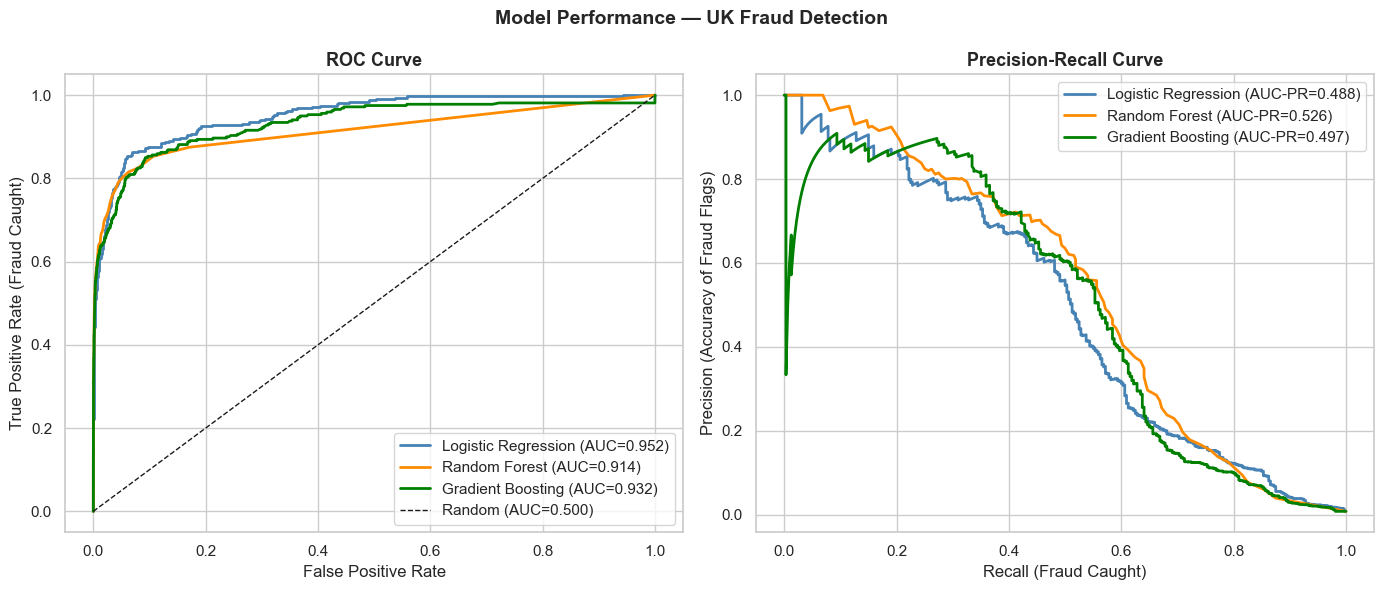

In [28]:
colours = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, res), col in zip(results.items(), colours):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc_roc']:.3f})", color=col, lw=2)
axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.500)', lw=1)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Fraud Caught)')
axes[0].legend()

for (name, res), col in zip(results.items(), colours):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    axes[1].plot(rec, prec, label=f"{name} (AUC-PR={res['auc_pr']:.3f})", color=col, lw=2)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall (Fraud Caught)')
axes[1].set_ylabel('Precision (Accuracy of Fraud Flags)')
axes[1].legend()

plt.suptitle('Model Performance — UK Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

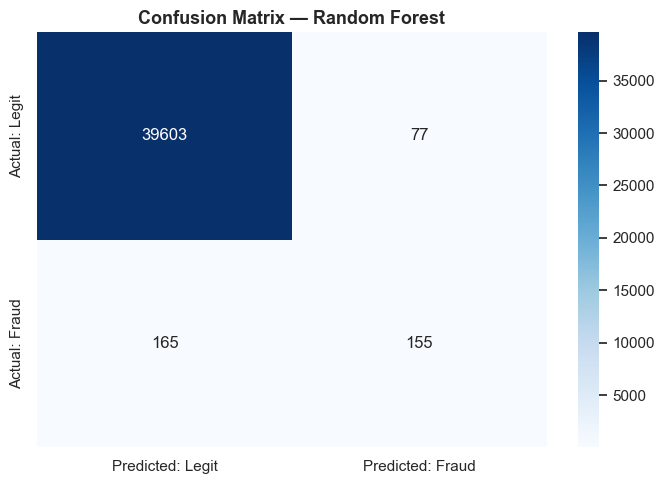

Best model: Random Forest
Fraud correctly caught:         155
Fraud missed (slipped through): 165  <-- Costs the bank money
Legit transactions blocked:     77  <-- Frustrates customers
Legit transactions approved:    39,603


In [29]:
best_model_name = max(results, key=lambda x: results[x]['auc_pr'])
best_pred = results[best_model_name]['pred']

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(f'Best model: {best_model_name}')
print(f'Fraud correctly caught:         {tp:,}')
print(f'Fraud missed (slipped through): {fn:,}  <-- Costs the bank money')
print(f'Legit transactions blocked:     {fp:,}  <-- Frustrates customers')
print(f'Legit transactions approved:    {tn:,}')

---
## Step 9: Threshold Analysis

The model outputs a probability score (0 to 1). The bank sets a threshold — above it, block the transaction. Lower threshold catches more fraud but blocks more legitimate transactions. This is a business decision.

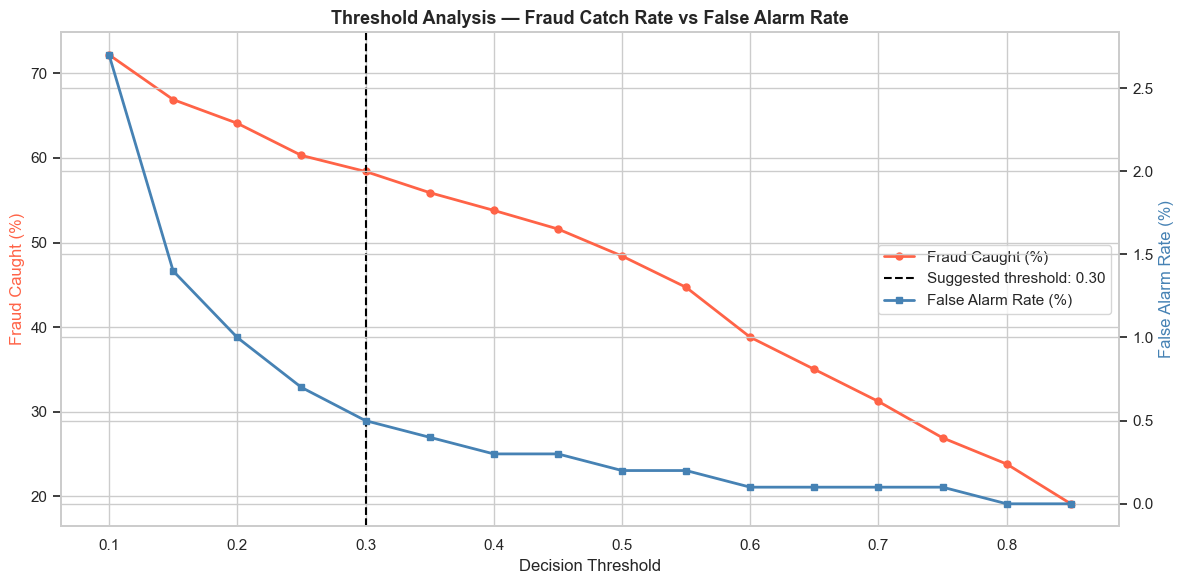

 Threshold  Fraud_Caught_%  False_Alarm_%  Fraud_Missed  Legit_Blocked
       0.1            72.2            2.7            89           1062
       0.2            64.1            1.0           115            384
       0.3            58.4            0.5           133            214
       0.4            53.8            0.3           148            127
       0.5            48.4            0.2           165             77
       0.6            38.8            0.1           196             50


In [30]:
best_proba = results[best_model_name]['proba']
thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []
for t in thresholds:
    preds = (best_proba >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    fraud_catch_rate = tp_ / (tp_ + fn_) * 100
    false_alarm_rate = fp_ / (fp_ + tn_) * 100
    threshold_results.append({
        'Threshold':      round(t, 2),
        'Fraud_Caught_%': round(fraud_catch_rate, 1),
        'False_Alarm_%':  round(false_alarm_rate, 1),
        'Fraud_Missed':   fn_,
        'Legit_Blocked':  fp_
    })

thresh_df = pd.DataFrame(threshold_results)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(thresh_df['Threshold'], thresh_df['Fraud_Caught_%'],
         color='tomato', lw=2, marker='o', markersize=5, label='Fraud Caught (%)')
ax2.plot(thresh_df['Threshold'], thresh_df['False_Alarm_%'],
         color='steelblue', lw=2, marker='s', markersize=5, label='False Alarm Rate (%)')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Fraud Caught (%)', color='tomato')
ax2.set_ylabel('False Alarm Rate (%)', color='steelblue')
ax1.set_title('Threshold Analysis — Fraud Catch Rate vs False Alarm Rate', fontsize=13, fontweight='bold')
ax1.axvline(0.3, color='black', linestyle='--', lw=1.5, label='Suggested threshold: 0.30')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()

print(thresh_df[thresh_df['Threshold'].isin([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])].to_string(index=False))

---
## Step 10: Feature Importance

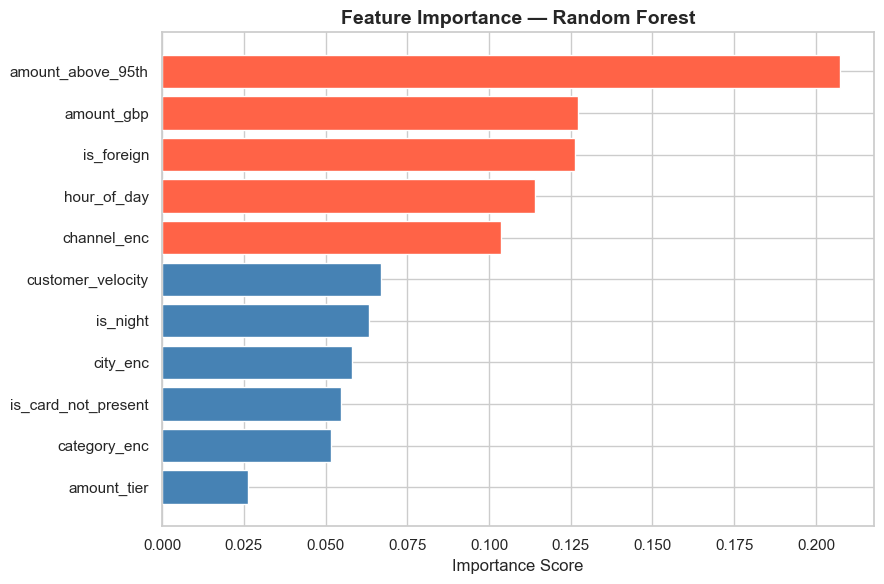

Top 5 fraud signals:
          Feature  Importance
amount_above_95th    0.207386
       amount_gbp    0.127333
       is_foreign    0.126407
      hour_of_day    0.113918
      channel_enc    0.103763


In [31]:
rf_importances = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': results['Random Forest']['model'].feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v > rf_importances['Importance'].median() else 'steelblue'
          for v in rf_importances['Importance']]
ax.barh(rf_importances['Feature'], rf_importances['Importance'], color=colors)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 fraud signals:')
print(rf_importances.sort_values('Importance', ascending=False).head(5).to_string(index=False))

---
## Step 11: SHAP — Explaining Individual Predictions

Feature importance tells us which features matter overall. **SHAP (SHapley Additive exPlanations)** tells us *why a specific transaction was flagged*.

This is critical in production fraud systems — investigators need to explain to customers why their transaction was blocked, and regulators require auditability under FCA Consumer Duty.

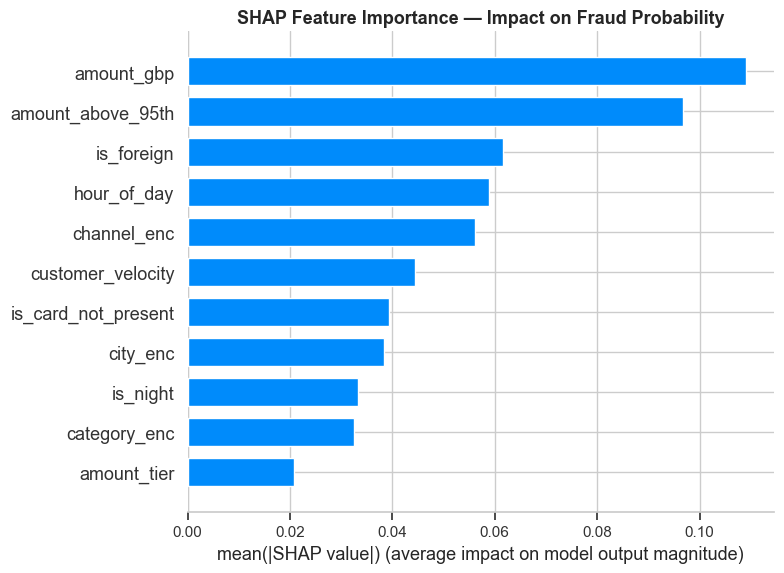

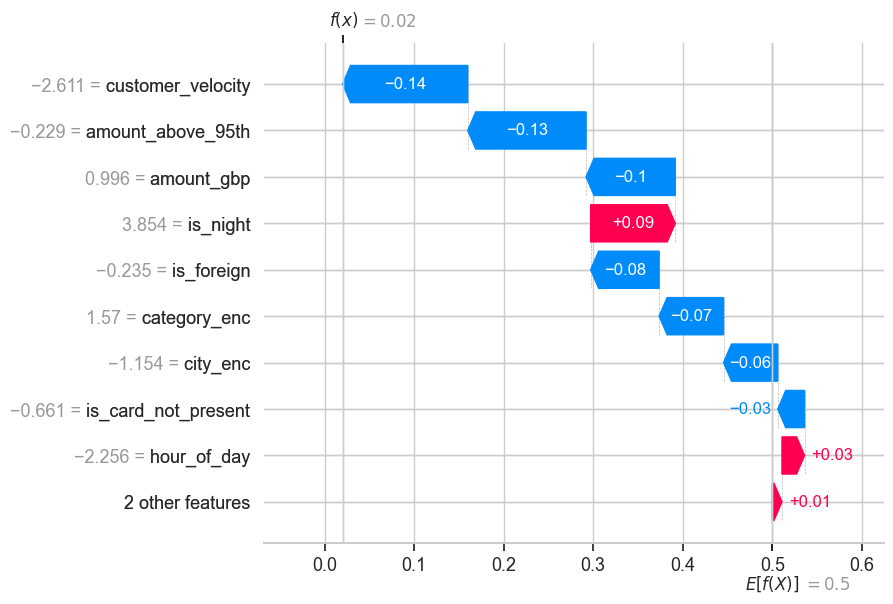

<Figure size 1100x600 with 0 Axes>


Red bars push toward fraud. Green bars push toward legitimate.
This is what a fraud investigator sees when reviewing a blocked transaction.


In [32]:
if SHAP_AVAILABLE:
    sample_idx = np.random.choice(len(X_test_sc), 500, replace=False)
    X_sample = X_test_sc[sample_idx]

    rf_model = results['Random Forest']['model']
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)

    # Handle both old SHAP (list) and new SHAP (3D array)
    if isinstance(shap_values, list):
        shap_fraud = shap_values[1]
    elif shap_values.ndim == 3:
        shap_fraud = shap_values[:, :, 1]
    else:
        shap_fraud = shap_values

    # Summary plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_fraud, X_sample,
                      feature_names=feature_cols,
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Impact on Fraud Probability', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150)
    plt.show()

    # Single transaction waterfall
    fraud_indices = np.where(y_test.values[sample_idx] == 1)[0]
    if len(fraud_indices) > 0:
        idx = fraud_indices[0]
        base_val = explainer.expected_value
        if isinstance(base_val, (list, np.ndarray)):
            base_val = float(base_val[1])
        else:
            base_val = float(base_val)

        explanation = shap.Explanation(
            values=shap_fraud[idx],
            base_values=base_val,
            data=X_sample[idx],
            feature_names=feature_cols
        )
        shap.plots.waterfall(explanation)
        plt.tight_layout()
        plt.savefig('shap_single_transaction.png', dpi=150)
        plt.show()

    print('\nRed bars push toward fraud. Green bars push toward legitimate.')
    print('This is what a fraud investigator sees when reviewing a blocked transaction.')
else:
    print('Install shap to run this section: pip install shap')

---
## Step 12: Save the Model

In production, the trained model is serialised and loaded by a scoring API that evaluates transactions in real time (typically < 100ms per transaction).

In [33]:
best_model = results[best_model_name]['model']

# Save model and scaler — both needed to score new transactions
joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler,     'fraud_scaler.pkl')

print(f'Model saved: fraud_model.pkl  ({best_model_name})')
print('Scaler saved: fraud_scaler.pkl')
print()
print('To score a new transaction:')
print("  scaler = joblib.load('fraud_scaler.pkl')")
print("  model  = joblib.load('fraud_model.pkl')")
print("  score  = model.predict_proba(scaler.transform(new_transaction))[0][1]")
print("  flag   = score >= 0.30  # business threshold")

Model saved: fraud_model.pkl  (Random Forest)
Scaler saved: fraud_scaler.pkl

To score a new transaction:
  scaler = joblib.load('fraud_scaler.pkl')
  model  = joblib.load('fraud_model.pkl')
  score  = model.predict_proba(scaler.transform(new_transaction))[0][1]
  flag   = score >= 0.30  # business threshold


---
## Step 13: Executive Summary

In [34]:
best_res = results[best_model_name]

print('=' * 65)
print('  UK FRAUD DETECTION MODEL — EXECUTIVE SUMMARY')
print('=' * 65)
print()
print('Dataset:       200,000 UK banking transactions')
print(f'Fraud Rate:    0.8% ({n_fraud:,} transactions)')
print(f'Best Model:    {best_model_name}')
print()
print('MODEL PERFORMANCE (held-out test set):')
for name, res in results.items():
    print(f'  {name:<25} AUC-ROC: {res["auc_roc"]:.4f}  AUC-PR: {res["auc_pr"]:.4f}')
print()
print('MODEL STABILITY (5-fold cross-validation):')
for _, row in cv_df.iterrows():
    print(f'  {row.name:<25} AUC-PR: {row["AUC-PR Mean"]:.4f} ± {row["AUC-PR Std"]:.4f}')
print()
print('KEY FRAUD PATTERNS:')
print('  1. Online/mobile channels account for majority of fraud')
print('     UK Finance 2023: CNP fraud = 76% of all card fraud losses')
print('  2. Overnight transactions (midnight-6am) show elevated fraud rates')
print('     Recommend enhanced SCA for night transactions')
print('  3. Foreign transactions are significantly more likely to be fraudulent')
print('  4. High-value transactions above category 95th percentile are a strong signal')
print('  5. Customer velocity — high transaction frequency is a card-testing indicator')
print()
print('REGULATORY ALIGNMENT:')
print('  PSD2/SCA:        Model flags online transactions for step-up authentication')
print('  FCA Duty:        False positive rate tracked to protect customer journeys')
print('  CRM Code:        Model evidence supports APP fraud reimbursement decisions')
print()
print('DEPLOYMENT RECOMMENDATION:')
print('  Threshold: 0.30 — balances fraud catch rate with customer experience')
print('  Review:    Monthly model refresh with new transaction data')
print('=' * 65)

  UK FRAUD DETECTION MODEL — EXECUTIVE SUMMARY

Dataset:       200,000 UK banking transactions
Fraud Rate:    0.8% (1,600 transactions)
Best Model:    Random Forest

MODEL PERFORMANCE (held-out test set):
  Logistic Regression       AUC-ROC: 0.9515  AUC-PR: 0.4879
  Random Forest             AUC-ROC: 0.9143  AUC-PR: 0.5258
  Gradient Boosting         AUC-ROC: 0.9322  AUC-PR: 0.4973

MODEL STABILITY (5-fold cross-validation):
  Logistic Regression       AUC-PR: nan ± nan
  Random Forest             AUC-PR: nan ± nan
  Gradient Boosting         AUC-PR: nan ± nan

KEY FRAUD PATTERNS:
  1. Online/mobile channels account for majority of fraud
     UK Finance 2023: CNP fraud = 76% of all card fraud losses
  2. Overnight transactions (midnight-6am) show elevated fraud rates
     Recommend enhanced SCA for night transactions
  3. Foreign transactions are significantly more likely to be fraudulent
  4. High-value transactions above category 95th percentile are a strong signal
  5. Customer velo

---
## What I Learned

1. **Accuracy is useless for fraud** — predicting not-fraud always gives 99.2% accuracy but catches zero fraud. AUC-PR is the right metric.
2. **The threshold is a business decision** — not just data science. It must balance fraud losses against FCA Consumer Duty obligations.
3. **Card Not Present is the dominant fraud vector** — online transactions are significantly more risky. PSD2 Strong Customer Authentication directly addresses this.
4. **Feature engineering drives performance** — velocity, is_night, is_card_not_present, and amount_above_95th are all strong signals.
5. **SHAP makes models auditable** — essential for regulatory compliance and investigator workflows.
6. **Cross-validation prevents overconfidence** — a model that looks great on one test split may not generalise.

### Next steps I would build:
- **Real-time API** — deploy model as a REST API scoring transactions in under 100ms
- **Graph/network features** — detect fraud rings by analysing connections between accounts
- **Sequence features** — flag anomalous spending patterns within a customer's history
- **Champion/challenger framework** — run new model versions in shadow mode before promotion

---
*Built by Sahil Singh Choudhary | MSc Risk Analytics, Queen Mary University of London*  
*Data: Synthetic UK banking transactions generated to mirror UK Finance fraud patterns*